In [16]:
import os

# GitHub Users ke liye instructions: Apni key yahan enter karein
os.environ['KAGGLE_USERNAME'] = "ENTER_YOUR_KAGGLE_USERNAME_HERE"
os.environ['KAGGLE_KEY'] = "ENTER_YOUR_KAGGLE_API_KEY_HERE"


In [15]:
!kaggle datasets download -d asdasdasasdas/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
import os
if os.path.exists('garbage-classification.zip'):
    # Remove the existing directory if it exists, to ensure a clean unzip
    if os.path.exists('garbage_data') and os.path.isdir('garbage_data'):
        !rm -rf garbage_data
    # Force overwrite all files without prompting using 'yes A'
    !yes A | unzip -o -q garbage-classification.zip -d garbage_data

replace garbage_data/Garbage classification/Garbage classification/cardboard/cardboard1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

Pehle aapne Kaggle ko apna Card (Username/Key) dikhaye.

Phir aapne Kaggle se Uski Zip File mangwayi.

Phir aapne us Zip file ko khol kar garbage_data ka folder bana diya taake hum images dekh sakein.

In [6]:
import os
import matplotlib.pyplot as plt
import cv2

# 1. Folder ka rasta jahan images hain
DATA_DIR = 'garbage_data/Garbage classification/Garbage classification'

# 2. Saari categories ke naam nikalna
categories = os.listdir(DATA_DIR)
print("Hamare paas yeh categories hain:", categories)

# 3. Har category mein kitni images hain yeh ginna (Count)
for category in categories:
    path = os.path.join(DATA_DIR, category)
    num_images = len(os.listdir(path))
    print(f"- {category}: {num_images} images")

Hamare paas yeh categories hain: ['cardboard', 'trash', 'plastic', 'glass', 'paper', 'metal']
- cardboard: 403 images
- trash: 137 images
- plastic: 482 images
- glass: 501 images
- paper: 594 images
- metal: 410 images


Yeh code kya kar raha hai?

os.listdir(DATA_DIR): Yeh aapke folder ke andar ja kar dekhta hai ke kitne sub-folders hain (jaise Plastic, Glass, Paper wagera).


len(os.listdir(path)): Yeh har ek folder ke andar ja kar ginti (count) karta hai ke Plastic ki kitni photos hain, Glass ki kitni hain, taake aapko pata chale aapka data kitna bada hai.

Part 2: Data Preprocessing (Images ko standard size mein lana)

In [7]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 1. Training Dataset banana (80% data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2, # 20% data validation aur test ke liye alag rakh rahe hain
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 2. Baki bache 20% data ko validation aur test mein aadha-aadha baantna
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Test set alag karna
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2) # Aadha data Test ke liye
val_ds = val_ds.skip(val_batches // 2)  # Aadha data Validation ke liye

print("Data successfully split ho gaya!")

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Data successfully split ho gaya!


Yeh code kya kar raha hai?

image_dataset_from_directory: Yeh TensorFlow ka ek bohoat aqalmand tool hai. Yeh khud hi folders ke naam ko "Labels" (targets) bana deta hai aur saari images ka size change karke $(224, 224)$ kar deta hai.

batch_size=32: Iska matlab hai computer ek waqt mein saari images nahi parhega, balki 32-32 images ke chote groups (batches) bana kar parhega taake computer hang na ho.

Step 3: AI Model (CNN)

In [8]:
from tensorflow.keras import layers, models

# 1. AI Model ka dacha (Sequential) shuru karna
model = models.Sequential([

    # Layer A: Normalization (Pixel values ko 0 se 1 ke darmiyan lana)
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # Layer B: Pehli Aankh (Feature Extraction)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer C: Doosri Aankh (Ghrai se dekhna)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer D: Teesri Aankh (Mazeed details pakadna)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Layer E: Data ko seedha karna (Flatten)
    layers.Flatten(),

    # Layer F: Dimaag ki samajh (Dense Layer)
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Yeh model ko ratta lagane (overfitting) se rokta hai

    # Layer G: Faisla (Output Layer - Hamari 6 classes ke liye)
    layers.Dense(6, activation='softmax')
])

# 2. Model ko parhai ke liye tayar (Compile) karna
model.compile(
    optimizer='adam', # Yeh model ko jaldi seekhne mein madad karta hai
    loss='sparse_categorical_crossentropy', # Jab bohot saari classes hon toh yeh use hota hai
    metrics=['accuracy'] # Hum check karenge ke kitne percent sahi jawab diye
)

# 3. Model ki summary dekhna
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Aasan Alfaaz mein samjhein yeh Layers kya kar rahi hain:

Rescaling(1./255): Images ke pixel numbers 0 se 255 tak hote hain. Computer ke liye itne bade numbers mushkil hote hain, isliye yeh layer sabko 0 aur 1 ke beech le aati hai taake calculation aasan ho.

Conv2D (Convolutional Layer): Yeh samajhein ek scanner hai jo image par ghoomta hai aur kachre ka pattern (jaise plastic ka gol dabba ya cardboard ka kona) dhoondta hai.

MaxPooling2D: Yeh scan ki hui image ko chota karta hai aur sirf sabse zaroori zaroori points ko aage bhejta hai taake computer hang na ho.

Flatten: Saari images 2D (chauras) hoti hain. Yeh layer unhein ek seedhi lambi line (1D vector) mein badal deti hai.

Dense: Yeh aam neural network layer hai jo faisla karti hai. Aakhri Dense layer mein humne 6 likha hai kyunki hamare paas total 6 kachre ki categories hain (Plastic, Paper, Glass, etc.).

Step 4: Model Training

Ab hum model ko bolenge ke jo humne data split kiya tha, us se seekhna shuru kare. Hum isko 10 Epochs (yaani 10 baar poori kitaab/dataset dohrana) tak parhayenge.

In [9]:
# Model ki training shuru
history = model.fit(
    train_ds,          # Is data se seekho
    validation_data=val_ds, # Aur is data se khud ko check karo ke sahi seekh rahe ho ya nahi
    epochs=10          # Kitaab ko 10 baar dohrao
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.2779 - loss: 1.9072 - val_accuracy: 0.4578 - val_loss: 1.4329
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.4090 - loss: 1.4591 - val_accuracy: 0.5060 - val_loss: 1.2971
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.4590 - loss: 1.3449 - val_accuracy: 0.4739 - val_loss: 1.3354
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.5010 - loss: 1.2593 - val_accuracy: 0.5221 - val_loss: 1.2607
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.5366 - loss: 1.1843 - val_accuracy: 0.5663 - val_loss: 1.2903
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.5861 - loss: 1.0770 - val_accuracy: 0.5743 - val_loss: 1.2432
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.6093 - loss: 1.0145 - val_accuracy: 0.5462 - val_loss: 1.1854
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.6316 - loss: 0.9804 - val_accuracy: 0.5622 - v

Jab 10 epochs poore ho gaye hain, toh iska matlab hai aapke AI model ne kachre ki pictures ko pehchanna seekh liya hai.

Step 5: Learning Curves Plot (Accuracy and Loss Graph)

1.   Accuracy Graph: Yeh dikhayega ke waqt ke sath model kitna hoshiyar hua.

2.   Loss Graph: Yeh dikhayega ke waqt ke sath model ki galtiyan kitni kam hueen.
   



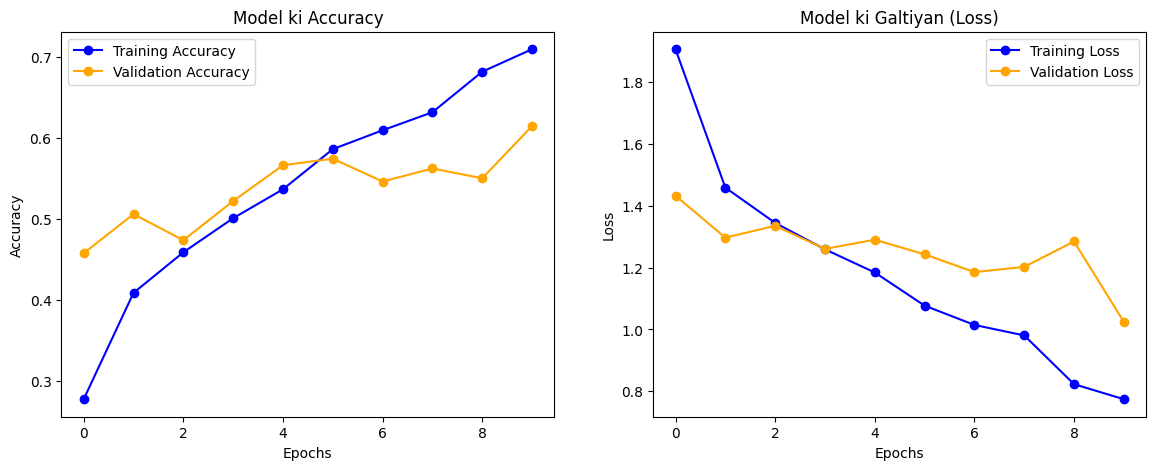

In [10]:
import matplotlib.pyplot as plt

# History se accuracy aur loss ki details nikalna
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(10) # Kyunki humne 10 epochs chalaye the

# Graph banane ka code
plt.figure(figsize=(14, 5))

# 1. Accuracy ka Graph
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='o')
plt.title('Model ki Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Loss ka Graph
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('Model ki Galtiyan (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Step 6: Final Test Set (Accuracy Check)

In [11]:
# Final evaluation
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n🎯 Final Test Accuracy: {test_acc*100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 564ms/step - accuracy: 0.5781 - loss: 1.2616

🎯 Final Test Accuracy: 57.81%


Step 7: Confusion Matrix (Yeh dekhna ke model kahan confuse ho raha hai)

Confusion Matrix se aapko ek table milega jo saaf-saaf batayega ke, srf misal ke tor par, model kitni baar Plastic ko galti se Glass samajh baitha. Yeh aapki report ke liye bohot zaroori hai.

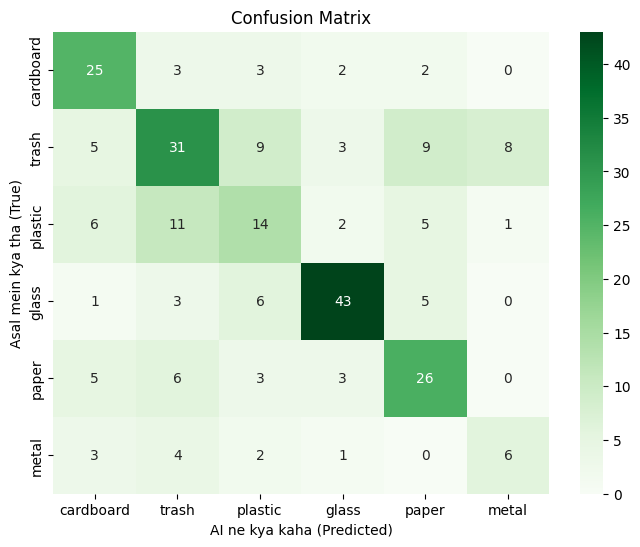


📝 Detailed Classification Report:
              precision    recall  f1-score   support

   cardboard       0.56      0.71      0.62        35
       trash       0.53      0.48      0.50        65
     plastic       0.38      0.36      0.37        39
       glass       0.80      0.74      0.77        58
       paper       0.55      0.60      0.58        43
       metal       0.40      0.38      0.39        16

    accuracy                           0.57       256
   macro avg       0.54      0.55      0.54       256
weighted avg       0.57      0.57      0.56       256



In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Test data se sahi jawab (true labels) aur model ke jawab (predictions) nikalna
true_labels = []
pred_labels = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_labels.extend(np.argmax(preds, axis=1))
    true_labels.extend(labels.numpy())

# Confusion Matrix ka graph banana
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories, cmap='Greens')
plt.xlabel('AI ne kya kaha (Predicted)')
plt.ylabel('Asal mein kya tha (True)')
plt.title('Confusion Matrix')
plt.show()

# Classification Report (Precision, Recall, F1-Score)
print("\n📝 Detailed Classification Report:")
print(classification_report(true_labels, pred_labels, target_names=categories))

Step 8: 10 Unseen Images and Model  Predictions Display

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step


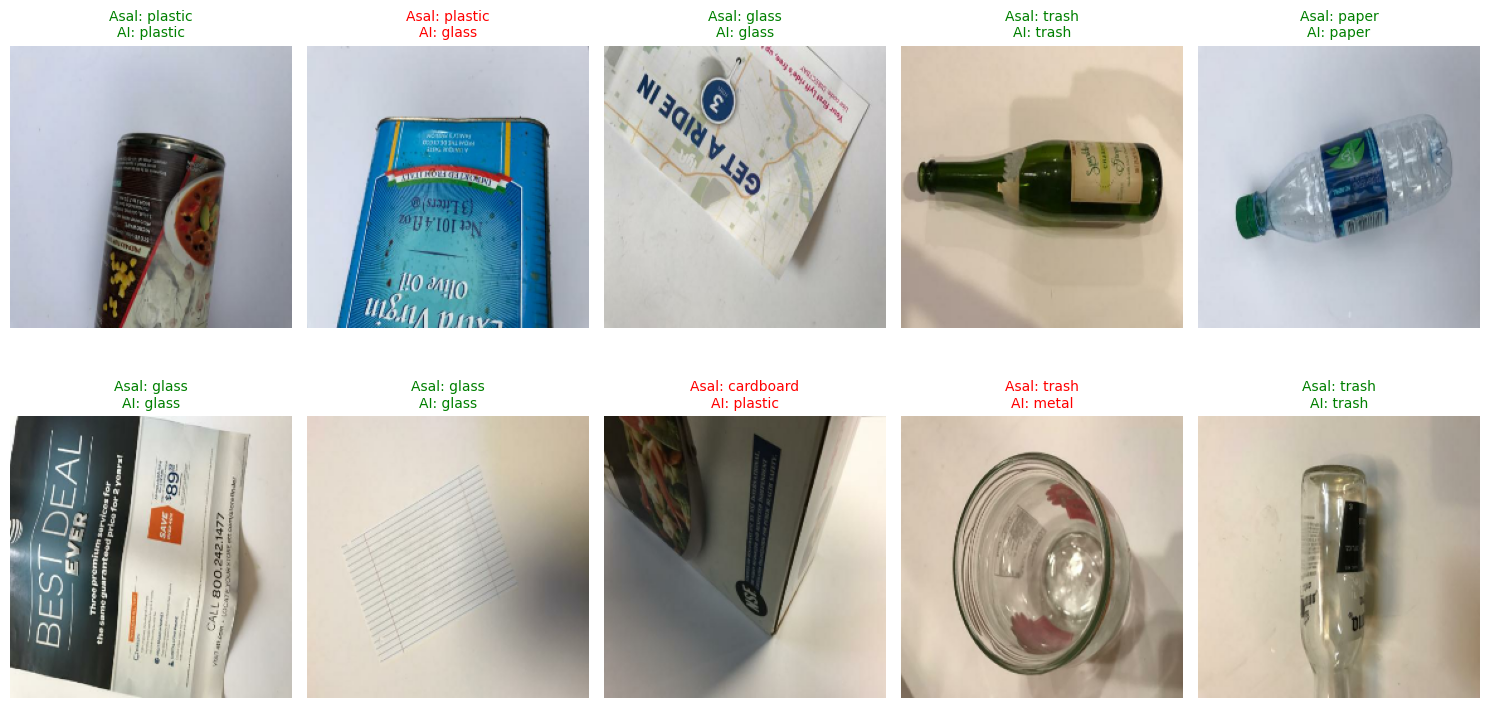

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Test set se ek batch (images) uthana
for images, labels in test_ds.take(1):
    # Model se predictions lena
    predictions = model.predict(images)

    # Screen par 10 pictures show karne ke liye plot set up karna
    plt.figure(figsize=(15, 8))

    for i in range(10): # 10 images display karni hain
        plt.subplot(2, 5, i + 1)

        # Image ko pixel values [0, 255] mein wapas convert karna display ke liye
        img = images[i].numpy().astype("uint8")
        plt.imshow(img)

        # Sahi jawab aur AI ka jawab nikalna
        actual_class = categories[labels[i]]
        predicted_class = categories[np.argmax(predictions[i])]

        # Title set karna (Agar AI ka jawab sahi hai toh Green, galat hai toh Red)
        color = 'green' if actual_class == predicted_class else 'red'
        plt.title(f"Asal: {actual_class}\nAI: {predicted_class}", color=color, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    break